In [2]:
#STEP 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Dense
from keras import regularizers
import tensorflow as tf


In [3]:
# STEP 2: Load and Explore the Dataset

df = pd.read_csv("synthetic_iot_dataset.csv")
df.head()


,temperature,humidity,gasLevel,co2Level,airQuality,soundLevel,motionDetected,lightIntensity,vibrationLevel,deviceBattery,isAnomaly
0,46,132,0,0,0,0,0,754,0,0,1
1,22,53,60,424,48,20,0,116,8,88,0
2,27,45,92,565,52,46,1,180,1,51,0
3,53,130,0,0,0,112,0,611,0,0,1
4,28,42,89,578,65,32,0,220,6,70,0


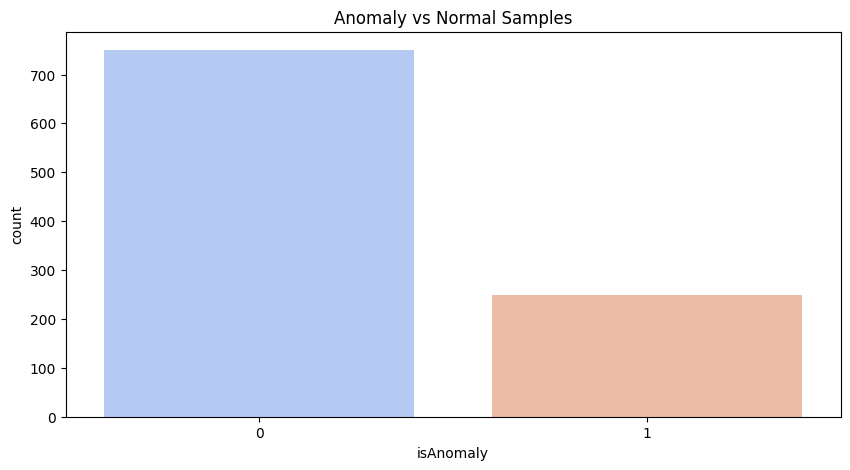

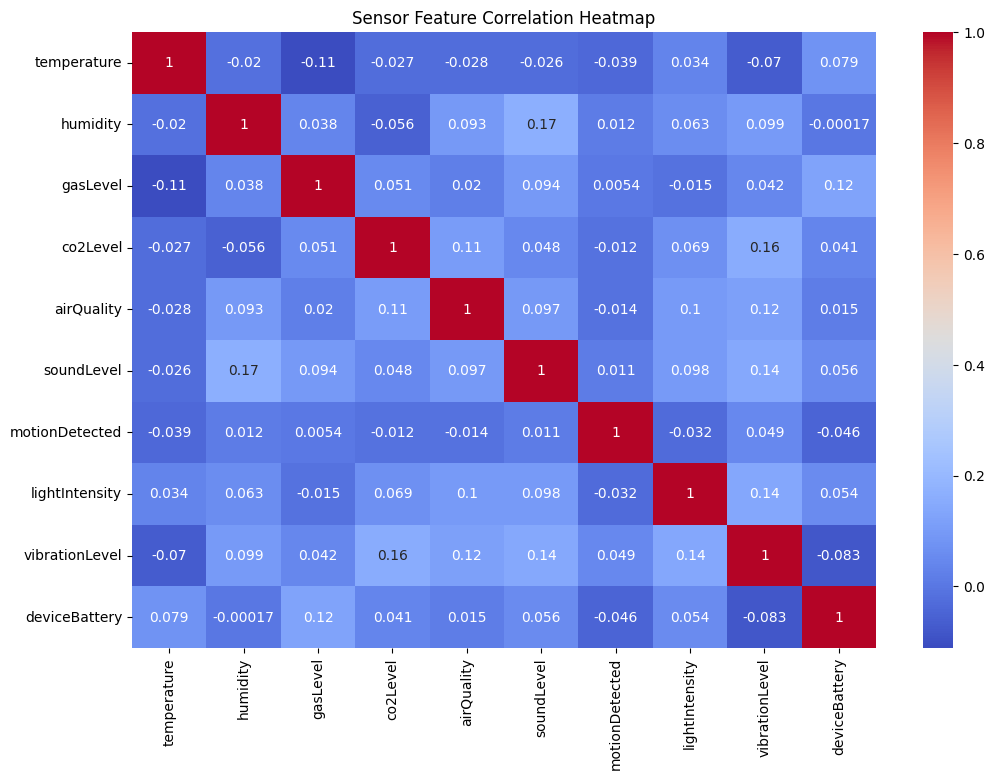

In [4]:
#STEP 3: Basic Visualization

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='isAnomaly', hue='isAnomaly', palette='coolwarm', legend=False)
plt.title("Anomaly vs Normal Samples")
plt.show()

# Correlation heatmap (Optional but great for presentation)
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['isAnomaly']).corr(), annot=True, cmap='coolwarm')
plt.title("Sensor Feature Correlation Heatmap")
plt.show()




In [5]:
#STEP 4: Preprocess Data
X = df.drop(columns=["isAnomaly", "deviceId", "timestamp", "timestamp_human"], errors='ignore')
y = df["isAnomaly"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
print(df.head())
print(df.shape)
print(df['isAnomaly'].value_counts())


   temperature  humidity  gasLevel  co2Level  airQuality  soundLevel  \
0           46       132         0         0           0           0   
1           22        53        60       424          48          20   
2           27        45        92       565          52          46   
3           53       130         0         0           0         112   
4           28        42        89       578          65          32   

   motionDetected  lightIntensity  vibrationLevel  deviceBattery  isAnomaly  
0               0             754               0              0          1  
1               0             116               8             88          0  
2               1             180               1             51          0  
3               0             611               0              0          1  
4               0             220               6             70          0  
(1000, 11)
isAnomaly
0    750
1    250
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

# ✅ Select features (excluding labels and timestamp)
features = [
    'temperature', 'humidity', 'gasLevel', 'co2Level', 'airQuality',
    'soundLevel', 'motionDetected', 'lightIntensity', 'vibrationLevel', 'deviceBattery'
]

X = df[features]
y = df['isAnomaly']  # Labels

# ✅ Normalize the feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
#STEP 5 Train isolation
iso_forest = IsolationForest(n_estimators=100, contamination=0.2, random_state=42)
iso_preds = iso_forest.fit_predict(X_scaled)

# Convert to 0 (normal) and 1 (anomaly)
iso_preds = np.where(iso_preds == -1, 1, 0)

print("🔍 Isolation Forest Evaluation:")
print(confusion_matrix(y, iso_preds))
print(classification_report(y, iso_preds))



🔍 Isolation Forest Evaluation:
[[750   0]
 [ 50 200]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       750
           1       1.00      0.80      0.89       250

    accuracy                           0.95      1000
   macro avg       0.97      0.90      0.93      1000
weighted avg       0.95      0.95      0.95      1000



In [9]:
#STEP 5B Train Autoencoder Model
# Split normal and anomaly
X_normal = X_scaled[y == 0]
X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)

input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_val, X_val), verbose=1)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2107 - val_loss: 0.1971
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1878 - val_loss: 0.1824
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1740 - val_loss: 0.1671
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1562 - val_loss: 0.1435
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1319 - val_loss: 0.1116
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0990 - val_loss: 0.0838
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0752 - val_loss: 0.0725
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0670 - val_loss: 0.0685
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0620 - val_loss: 0.0655
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0604 - val_loss: 0.0629
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0582 - val_loss: 0.0607
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0558 - val_l

In [10]:
#STEP6 Evaluate Autoencoder:
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)
threshold = np.percentile(mse[y == 0], 95)
auto_preds = (mse > threshold).astype(int)

print("🧠 Autoencoder Evaluation:")
print(confusion_matrix(y, auto_preds))
print(classification_report(y, auto_preds))


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
🧠 Autoencoder Evaluation:
[[712  38]
 [  0 250]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       750
           1       0.87      1.00      0.93       250

    accuracy                           0.96      1000
   macro avg       0.93      0.97      0.95      1000
weighted avg       0.97      0.96      0.96      1000



In [12]:
#Step 9: Save the Trained Autoencoder Model

from tensorflow.keras.models import load_model

# Save model
# New Keras format
autoencoder.save('autoencoder_model.keras')


# Save scaler (used for normalization)
import joblib
joblib.dump(iso_forest, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
#Testing both models

In [13]:
#STEP1:1. Load the Models
# For Isolation Forest
import joblib
from tensorflow.keras.models import load_model

# Load Isolation Forest model and store in correct variable
iso_forest_model = joblib.load('isolation_forest_model.pkl')


# Load Autoencoder
autoencoder = load_model('autoencoder_model.keras', compile=False)




In [14]:
#STEP2:
#2. Prepare Test Data
# Separate features and label
X_test = df.drop(columns=['isAnomaly'])
y_true = df['isAnomaly']

# Scale features
X_test_scaled = scaler.transform(X_test)


In [15]:
#3. Predict Using Both Models

# Isolation Forest
iso_preds = iso_forest.predict(X_test_scaled)
iso_preds = [1 if p == -1 else 0 for p in iso_preds]

# Autoencoder
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.square(X_test_scaled - reconstructions), axis=1)
threshold = np.percentile(mse, 95)
auto_preds = [1 if e > threshold else 0 for e in mse]






32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [16]:
#Step 4: Compare Accuracy

from sklearn.metrics import classification_report, confusion_matrix

print("Isolation Forest Report:")
print(classification_report(y_true, iso_preds))

print("Autoencoder Report:")
print(classification_report(y_true, auto_preds))


Isolation Forest Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       750
           1       1.00      0.80      0.89       250

    accuracy                           0.95      1000
   macro avg       0.97      0.90      0.93      1000
weighted avg       0.95      0.95      0.95      1000

Autoencoder Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       750
           1       1.00      0.20      0.33       250

    accuracy                           0.80      1000
   macro avg       0.89      0.60      0.61      1000
weighted avg       0.84      0.80      0.75      1000



In [17]:

# Combine predictions - flag as anomaly if either model says so
combined_preds = [1 if (i == 1 or a == 1) else 0 for i, a in zip(iso_preds, auto_preds)]

# Then evaluate
print("Combined Model Report:")
print(classification_report(y_true, combined_preds))


Combined Model Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       750
           1       1.00      0.80      0.89       250

    accuracy                           0.95      1000
   macro avg       0.97      0.90      0.93      1000
weighted avg       0.95      0.95      0.95      1000



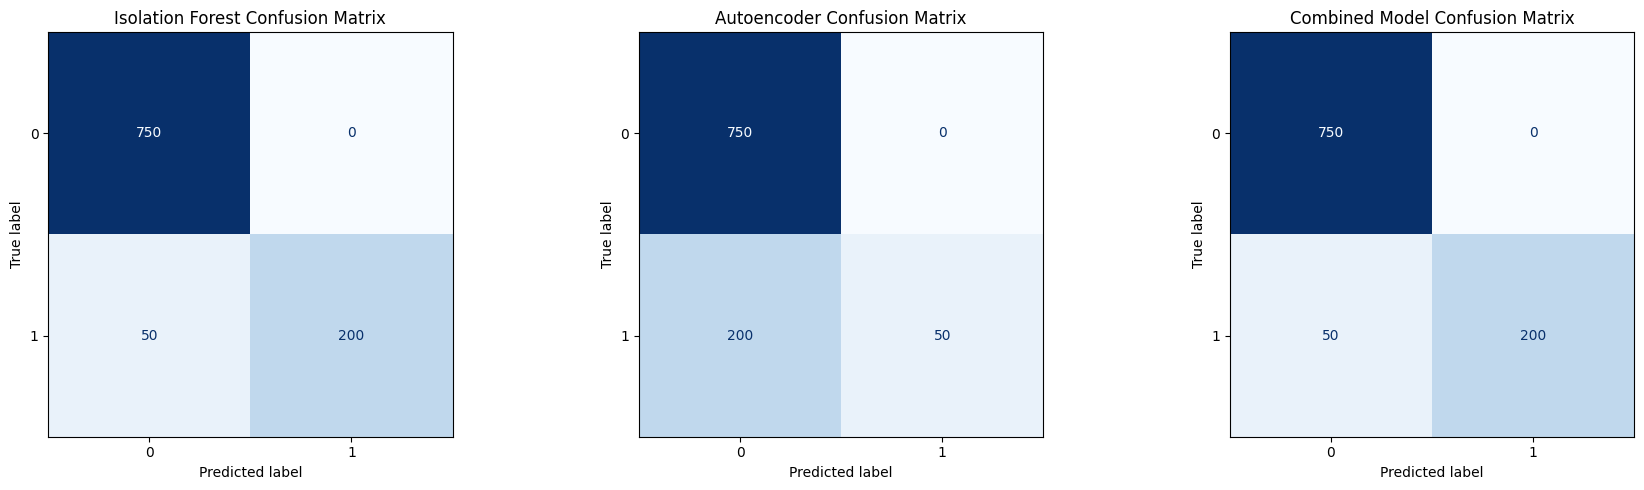

In [18]:
#1. Confusion Matrices for All Models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plotting all three confusion matrices
models = ['Isolation Forest', 'Autoencoder', 'Combined Model']
predictions = [iso_preds, auto_preds, combined_preds]

plt.figure(figsize=(18, 5))
for i, (name, preds) in enumerate(zip(models, predictions)):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    plt.subplot(1, 3, i + 1)
    disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
    plt.title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()


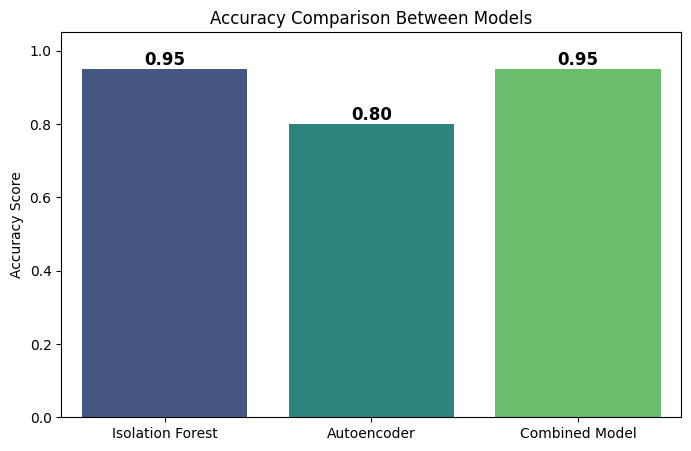

,Model,Precision,Recall,F1-Score
0,Isolation Forest,1.00,0.80,0.89
1,Autoencoder,1.00,0.20,0.33
2,Combined Model,1.00,0.80,0.89


In [19]:
#2. Bar Chart Comparing Accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy Comparison Bar Chart
accs = [
    accuracy_score(y_true, iso_preds),
    accuracy_score(y_true, auto_preds),
    accuracy_score(y_true, combined_preds)
]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accs, hue=models, dodge=False, palette="viridis", legend=False)
plt.title("Accuracy Comparison Between Models")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.05)
for i, acc in enumerate(accs):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=12, weight='bold')
plt.show()

# Classification Metrics Table
metrics = {
    'Model': models,
    'Precision': [precision_score(y_true, p) for p in predictions],
    'Recall': [recall_score(y_true, p) for p in predictions],
    'F1-Score': [f1_score(y_true, p) for p in predictions]
}
summary_df = pd.DataFrame(metrics)
summary_df.style.background_gradient(cmap='YlGnBu', axis=1).format(precision=2)

